In [1]:
import pandas as pd

# Load the dataset
file_path = '/kaggle/input/datasets/saifrehman63/water-pollution-data-project/Water Pollution Dataset (1).csv'
df = pd.read_csv(file_path)

# 1. Display the first 10 records
print("First 10 records:")
print(df.head(10))
print("-" * 30)

# 2. Number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("-" * 30)

# 3. Data types
print("Data types:")
print(df.dtypes)
print("-" * 30)

# 4. Missing values
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 30)

# 5. Descriptive statistics
print("Descriptive statistics:")
print(df.describe())
print("-" * 30)

# 6. Duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")
print("-" * 30)

# 7. Remove unnecessary columns (e.g., Sample_ID)
if 'Sample_ID' in df.columns:
    df = df.drop(columns=['Sample_ID'])
    print("Column 'Sample_ID' removed.")
else:
    print("'Sample_ID' not found in columns.")

# Display the dataframe after removing the column
print("\nDataFrame after cleaning:")
print(df.head())

First 10 records:
   Sample_ID   pH  Dissolved_Oxygen  Turbidity  Nitrate  Phosphate  BOD  \
0          1  7.2               8.9        3.2      1.5       0.10  2.1   
1          2  7.0               8.5        4.0      1.8       0.12  2.5   
2          3  7.3               8.8        3.8      1.6       0.11  2.3   
3          4  6.9               8.2        4.5      2.0       0.14  2.7   
4          5  7.1               8.6        3.5      1.7       0.13  2.4   
5          6  6.8               5.8       18.5      8.5       1.20  7.8   
6          7  6.7               5.5       20.2      9.1       1.35  8.2   
7          8  6.9               5.9       17.8      8.8       1.28  7.5   
8          9  6.6               5.3       21.0      9.5       1.40  8.8   
9         10  6.8               5.7       19.4      8.9       1.30  8.0   

   Temperature  Conductivity  
0           22           280  
1           23           300  
2           21           290  
3           24           310  
4

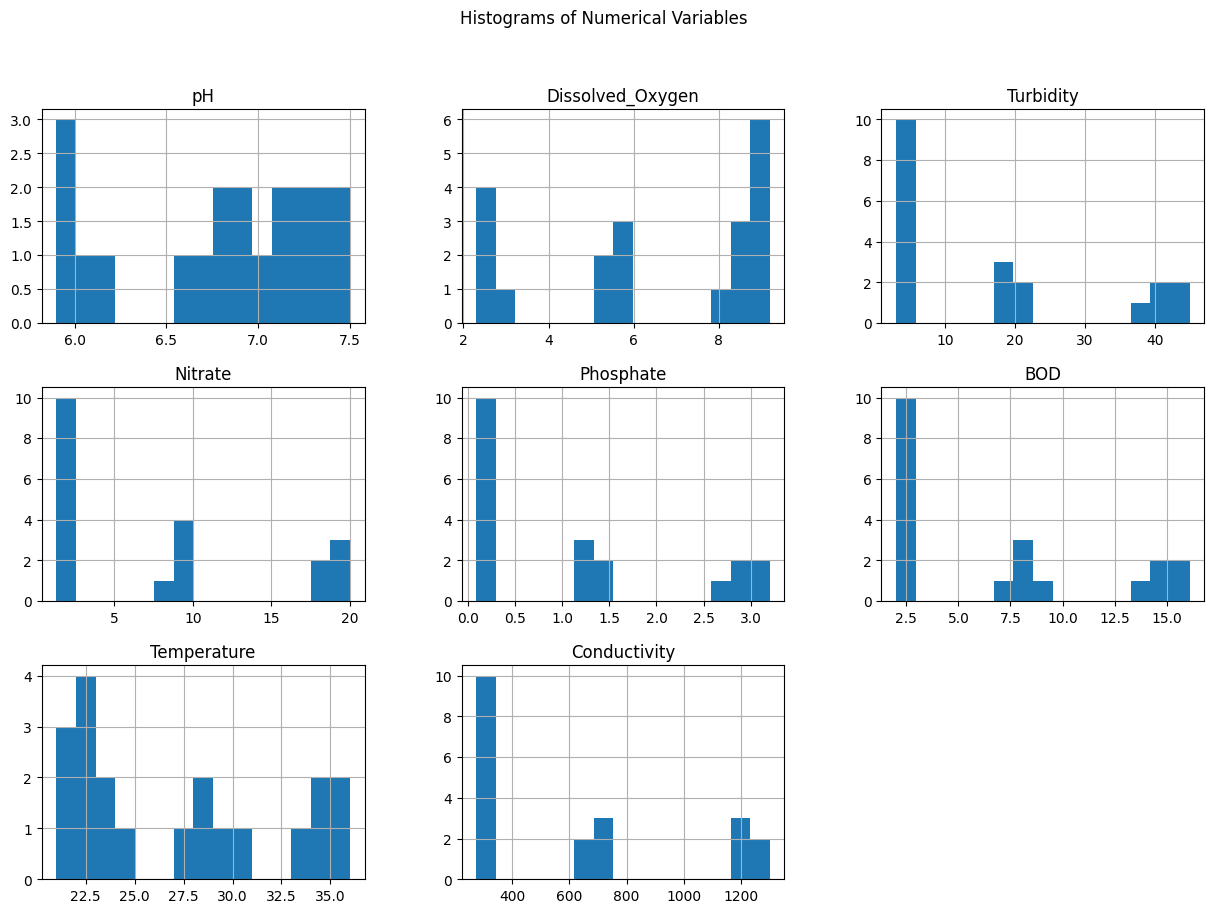

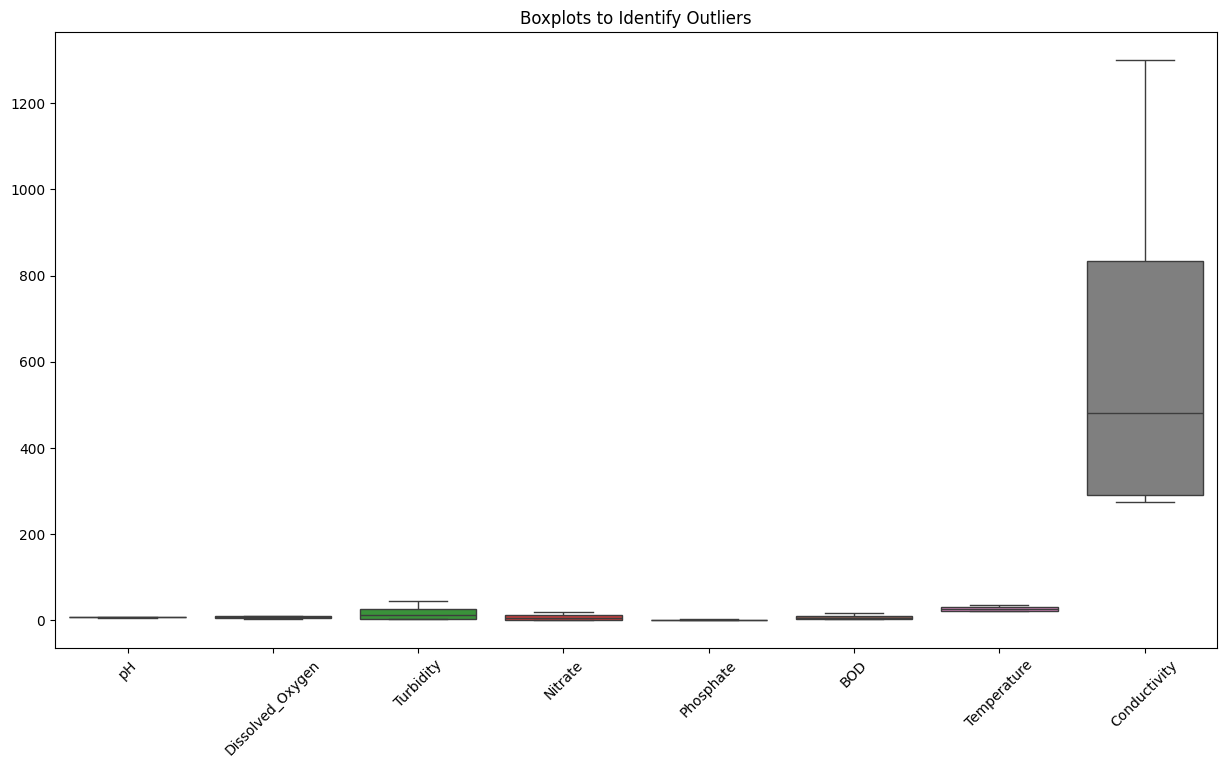

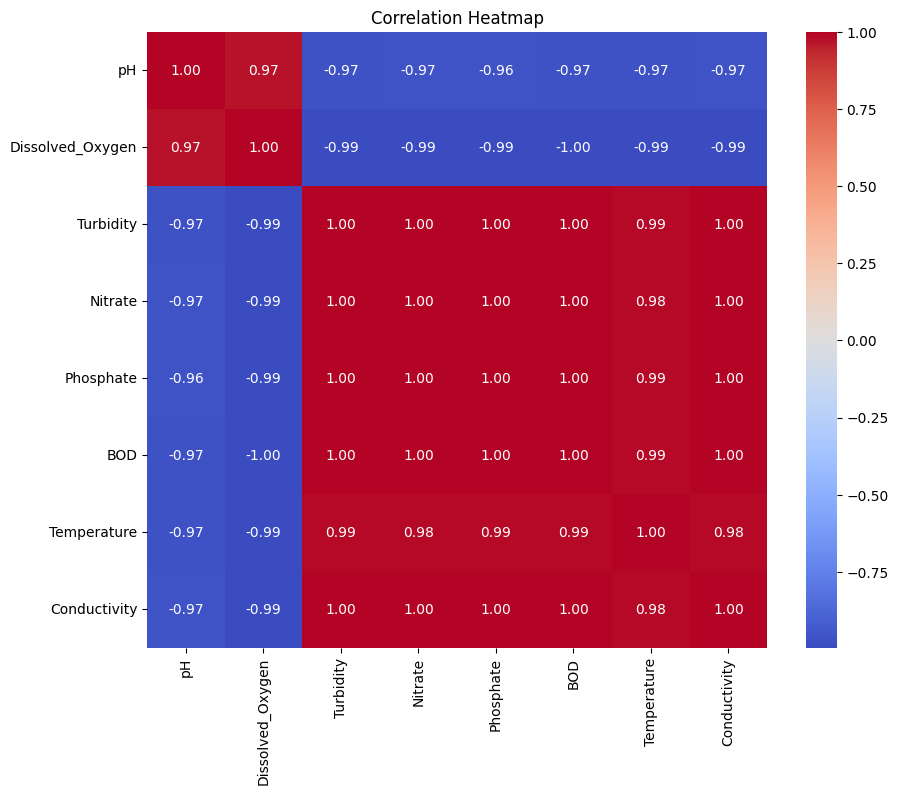

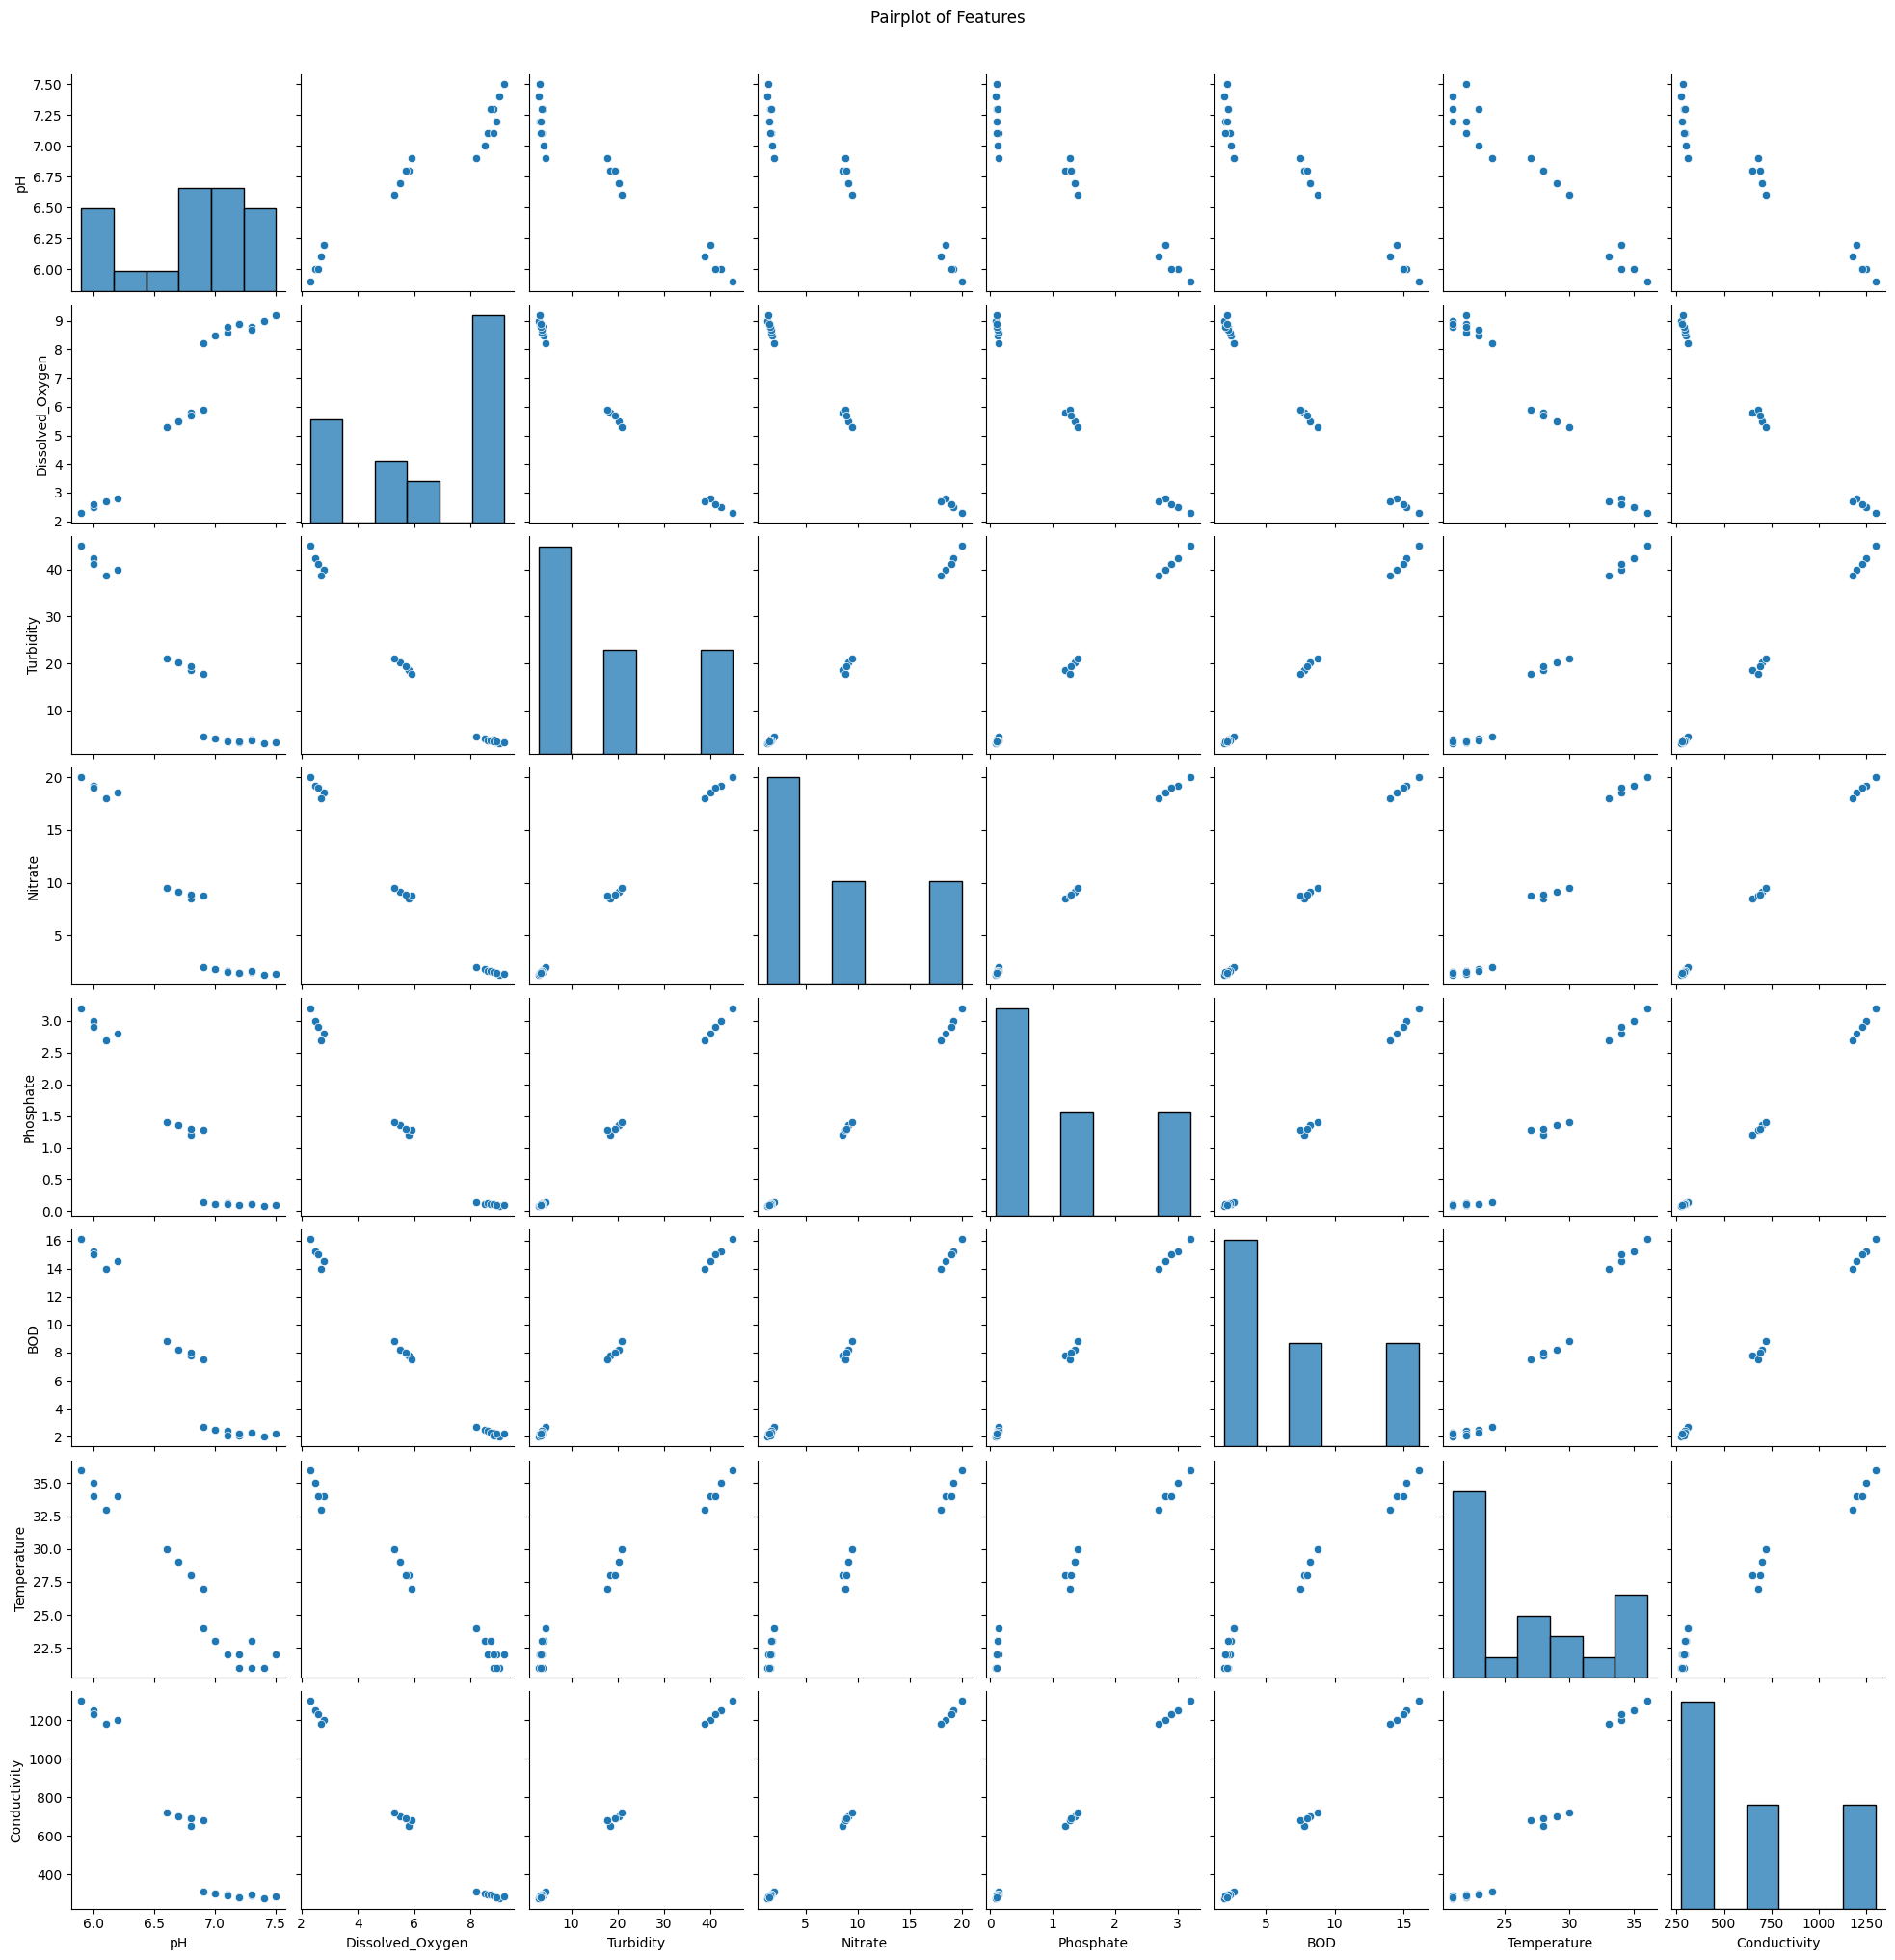

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame from Task 1 (with 'Sample_ID' removed)
# If starting fresh, uncomment the following lines:
# file_path = 'Water Pollution Dataset (1).csv'
# df = pd.read_csv(file_path)
# df = df.drop(columns=['Sample_ID'])

# 1. Histograms for all numerical variables
df.hist(bins=15, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Variables')
plt.show()

# 2. Boxplots to identify outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.title('Boxplots to Identify Outliers')
plt.xticks(rotation=45)
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 4. Pairplot
sns.pairplot(df)
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Handle missing values
# If there are missing values, you could impute them or drop them.
# Here we'll drop them, but you can also use df.fillna(df.mean())
df = df.dropna()

# 2. Remove duplicate records
df = df.drop_duplicates()

# 3. Standardize numerical features using StandardScaler
# K-Means is distance-based, so scaling is critical.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("Data scaled successfully.")
print(df_scaled.head())

Data scaled successfully.
         pH  Dissolved_Oxygen  Turbidity   Nitrate  Phosphate       BOD  \
0  0.808122          0.957307  -0.882908 -0.882160  -0.876215 -0.915345   
1  0.404061          0.801963  -0.831669 -0.840019  -0.858907 -0.838987   
2  1.010153          0.918471  -0.844479 -0.868113  -0.867561 -0.877166   
3  0.202031          0.685455  -0.799645 -0.811924  -0.841599 -0.800808   
4  0.606092          0.840799  -0.863694 -0.854066  -0.850253 -0.858076   

   Temperature  Conductivity  
0    -0.912660     -0.891277  
1    -0.720521     -0.839608  
2    -1.104799     -0.865442  
3    -0.528382     -0.813774  
4    -0.912660     -0.852525  


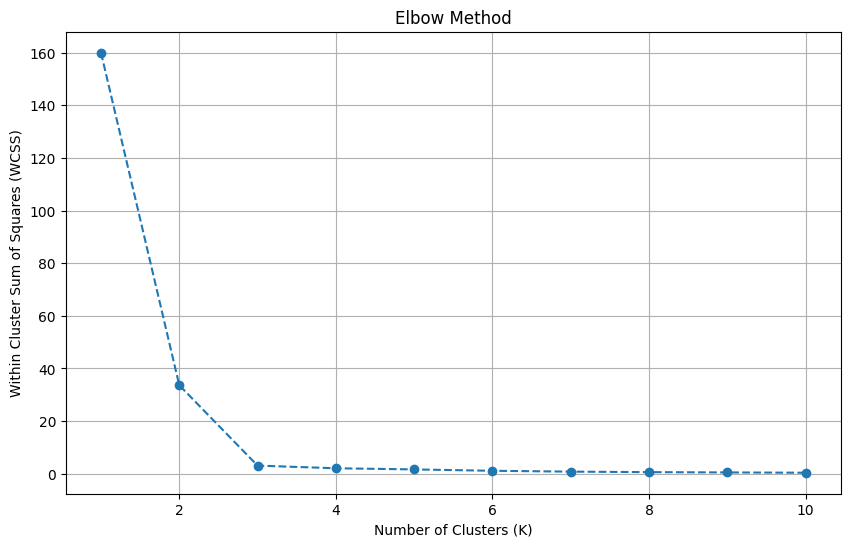

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming 'df_scaled' is your standardized data from Task 3
wcss = []
k_range = range(1, 11)

# Iterate through K from 1 to 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_) # 'inertia_' is the WCSS

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

In [5]:
# 1. Train the K-Means model with the optimal K (3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

# 2. Assign cluster labels to the original dataset
# We use the original 'df' (with Sample_ID removed) to add the labels
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

# 3. Calculate the number of samples in each cluster
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()

print("Number of samples in each cluster:")
print(cluster_counts)

# Display the first few rows with the cluster labels
print("\nFirst 5 records with assigned clusters:")
print(df_clustered.head())

Number of samples in each cluster:
Cluster
0     5
1     5
2    10
Name: count, dtype: int64

First 5 records with assigned clusters:
    pH  Dissolved_Oxygen  Turbidity  Nitrate  Phosphate  BOD  Temperature  \
0  7.2               8.9        3.2      1.5       0.10  2.1           22   
1  7.0               8.5        4.0      1.8       0.12  2.5           23   
2  7.3               8.8        3.8      1.6       0.11  2.3           21   
3  6.9               8.2        4.5      2.0       0.14  2.7           24   
4  7.1               8.6        3.5      1.7       0.13  2.4           22   

   Conductivity  Cluster  
0           280        2  
1           300        2  
2           290        2  
3           310        2  
4           295        2  


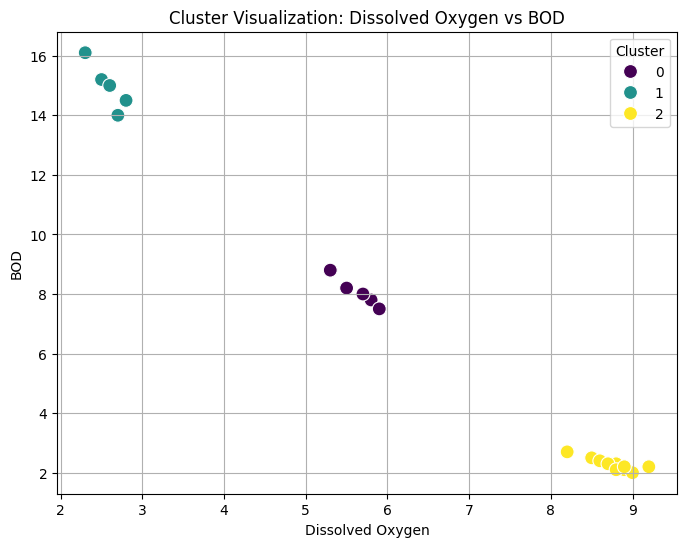

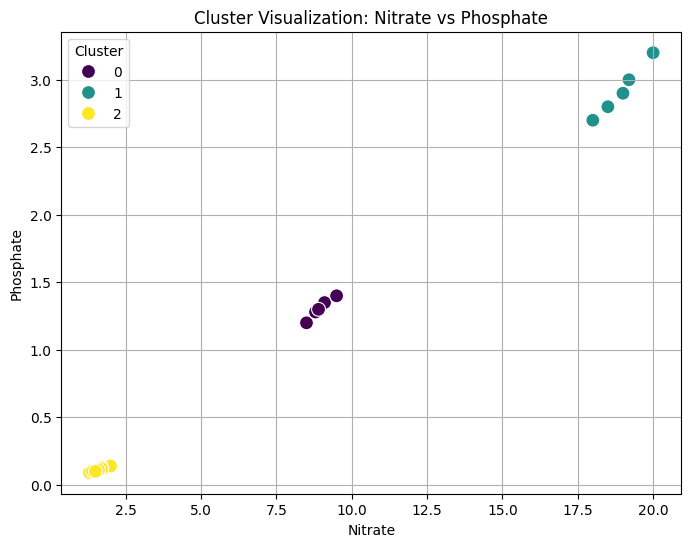

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df_clustered' contains your data with the 'Cluster' column

# 1. Visualization 1: Dissolved Oxygen vs BOD
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clustered, x='Dissolved_Oxygen', y='BOD', hue='Cluster', palette='viridis', s=100)
plt.title('Cluster Visualization: Dissolved Oxygen vs BOD')
plt.xlabel('Dissolved Oxygen')
plt.ylabel('BOD')
plt.grid(True)
plt.show()

# 2. Visualization 2: Nitrate vs Phosphate
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clustered, x='Nitrate', y='Phosphate', hue='Cluster', palette='viridis', s=100)
plt.title('Cluster Visualization: Nitrate vs Phosphate')
plt.xlabel('Nitrate')
plt.ylabel('Phosphate')
plt.grid(True)
plt.show()